In [36]:
import warnings
warnings.filterwarnings("ignore")

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA, TruncatedSVD

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.cluster import KMeans, AgglomerativeClustering

from sklearn.metrics import (
    roc_curve, auc,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    precision_recall_curve,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)


In [50]:
df = pd.read_csv("bird_counts.csv")
print(df.head())

   rownames  year              species          species_latin  count  hours  \
0         1  1921     American Bittern  Botaurus lentiginosus      0    8.0   
1         2  1921  American Black Duck          Anas rubripes      0    8.0   
2         3  1921        American Coot       Fulica americana      0    8.0   
3         4  1921        American Crow  Corvus brachyrhynchos      0    8.0   
4         5  1921   American Goldfinch         Spinus tristis      0    8.0   

   count_per_hour  count_per_week  
0             0.0             0.0  
1             0.0             0.0  
2             0.0             0.0  
3             0.0             0.0  
4             0.0             0.0  


In [51]:
df.shape

(18706, 8)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18706 entries, 0 to 18705
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   rownames        18706 non-null  int64  
 1   year            18706 non-null  int64  
 2   species         18706 non-null  object 
 3   species_latin   18706 non-null  object 
 4   count           18706 non-null  int64  
 5   hours           14925 non-null  float64
 6   count_per_hour  14925 non-null  float64
 7   count_per_week  14925 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.1+ MB


In [53]:
df.describe()

,rownames,year,count,hours,count_per_hour,count_per_week
count,18706.000000,18706.000000,18706.000000,14925.000000,14925.000000,14925.000000
mean,9353.500000,1970.361702,193.510959,170.842000,1.335703,224.398021
std,5400.101403,27.366206,1943.902699,45.601902,12.545440,2107.633976
min,1.000000,1921.000000,0.000000,8.000000,0.000000,0.000000
25%,4677.250000,1947.000000,0.000000,149.500000,0.000000,0.000000
50%,9353.500000,1970.500000,0.000000,171.000000,0.000000,0.000000
75%,14029.750000,1994.000000,5.000000,203.750000,0.051282,8.615385
max,18706.000000,2017.000000,73000.000000,251.000000,439.024390,73756.097561


In [54]:
df

,rownames,year,species,species_latin,count,hours,count_per_hour,count_per_week
0,1,1921,American Bittern,Botaurus lentiginosus,0,8.00,0.000000,0.000000
1,2,1921,American Black Duck,Anas rubripes,0,8.00,0.000000,0.000000
2,3,1921,American Coot,Fulica americana,0,8.00,0.000000,0.000000
3,4,1921,American Crow,Corvus brachyrhynchos,0,8.00,0.000000,0.000000
4,5,1921,American Goldfinch,Spinus tristis,0,8.00,0.000000,0.000000
...,...,...,...,...,...,...,...,...
18701,18702,2017,Winter Wren,Troglodytes hiemalis,9,198.75,0.045283,7.607547
18702,18703,2017,Wood Duck,Aix sponsa,1,198.75,0.005031,0.845283
18703,18704,2017,Yellow-bellied Sapsucker,Sphyrapicus varius,4,198.75,0.020126,3.381132
18704,18705,2017,Yellow-breasted Chat,Icteria virens,0,198.75,0.000000,0.000000


In [56]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
rownames             0
year                 0
species              0
species_latin        0
count                0
hours             3781
count_per_hour    3781
count_per_week    3781
dtype: int64


In [57]:
print(df['species'].value_counts())

species
American Bittern            94
American Black Duck         94
American Coot               94
American Crow               94
American Goldfinch          94
                            ..
Winter Wren                 94
Wood Duck                   94
Yellow-bellied Sapsucker    94
Yellow-breasted Chat        94
Yellow-rumped Warbler       94
Name: count, Length: 199, dtype: int64


In [58]:
# Target Variable

df["bird_present"] = (df["count"] > 0).astype(int)
df = df.drop(columns=["count", "count_per_hour", "count_per_week", "rownames"])

X = df.drop("bird_present", axis=1)
y = df["bird_present"]


numeric_features = ["year", "hours"]
categorical_features = ["species", "species_latin"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  
)

print("Training set class balance:", y_train.value_counts().to_dict())
print("Test set class balance:    ", y_test.value_counts().to_dict())

Training set class balance: {0: 9290, 1: 5674}
Test set class balance:     {0: 2323, 1: 1419}


In [59]:
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        C=1.0,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.8495456974879744
              precision    recall  f1-score   support

           0       0.91      0.84      0.87      2323
           1       0.77      0.86      0.81      1419

    accuracy                           0.85      3742
   macro avg       0.84      0.85      0.84      3742
weighted avg       0.86      0.85      0.85      3742



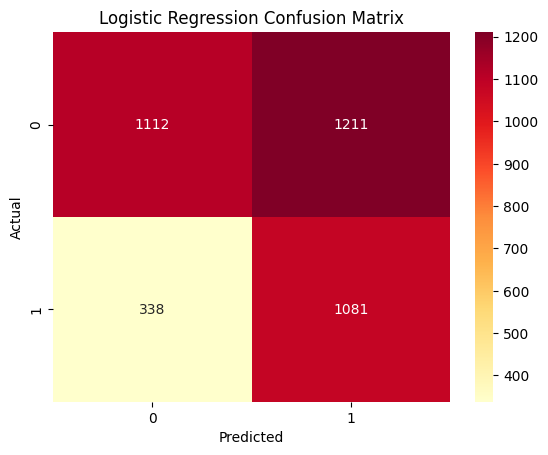

In [67]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap="YlOrRd")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [63]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

X_train_nb = preprocessor.fit_transform(X_train).toarray()
X_test_nb = preprocessor.transform(X_test).toarray()

nb_model = GaussianNB(var_smoothing=1e-8)
nb_model.fit(X_train_nb, y_train)

y_pred = nb_model.predict(X_test_nb)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Naive Bayes Accuracy: 0.780331373597007
              precision    recall  f1-score   support

           0       0.94      0.69      0.80      2323
           1       0.65      0.92      0.76      1419

    accuracy                           0.78      3742
   macro avg       0.79      0.81      0.78      3742
weighted avg       0.83      0.78      0.78      3742



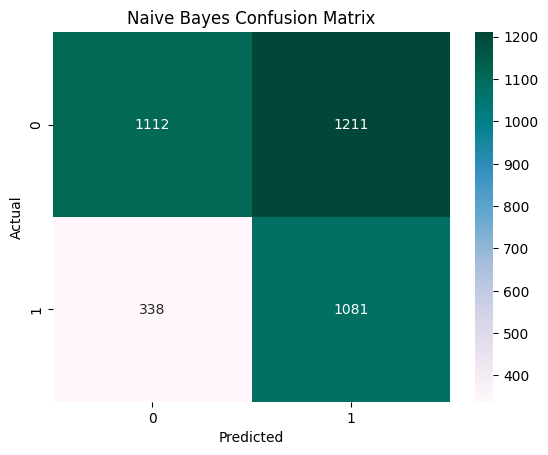

In [68]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap="PuBuGn")
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [65]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(
        n_neighbors=7,
        weights="distance",
        metric="minkowski"
    ))
])

knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

KNN Accuracy: 0.8869588455371459
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      2323
           1       0.86      0.84      0.85      1419

    accuracy                           0.89      3742
   macro avg       0.88      0.88      0.88      3742
weighted avg       0.89      0.89      0.89      3742



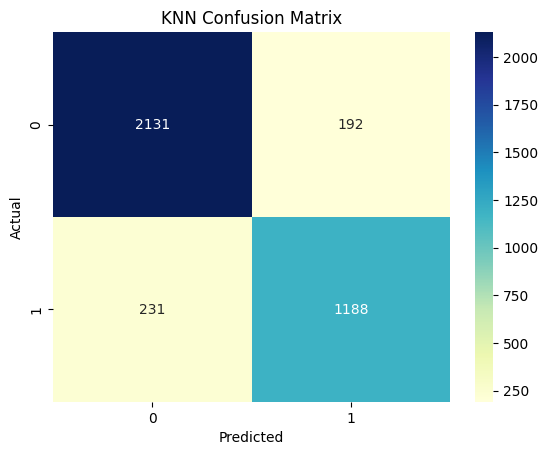

In [70]:
y_pred = knn_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap="YlGnBu")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [64]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        probability=True,
        C=5.0,
        kernel="rbf",
        gamma="scale",
        class_weight="balanced"
    ))
])

svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

SVM Accuracy: 0.8853554249064671
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      2323
           1       0.83      0.88      0.85      1419

    accuracy                           0.89      3742
   macro avg       0.88      0.88      0.88      3742
weighted avg       0.89      0.89      0.89      3742



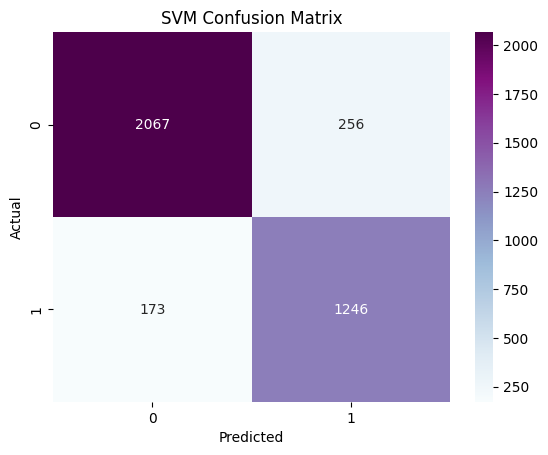

In [69]:
y_pred = svm_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap="BuPu")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Decision Tree Accuracy: 0.5860502405130946
              precision    recall  f1-score   support

           0       0.77      0.48      0.59      2323
           1       0.47      0.76      0.58      1419

    accuracy                           0.59      3742
   macro avg       0.62      0.62      0.59      3742
weighted avg       0.65      0.59      0.59      3742



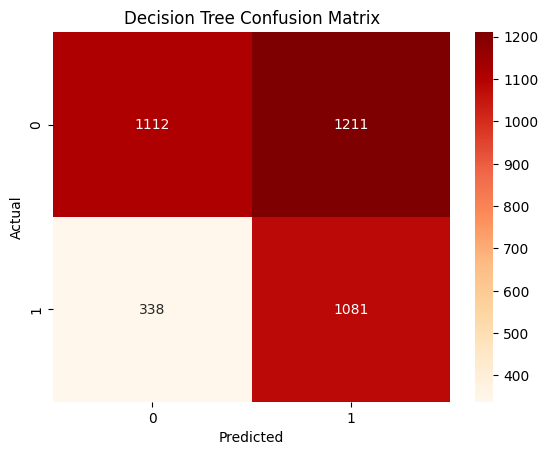

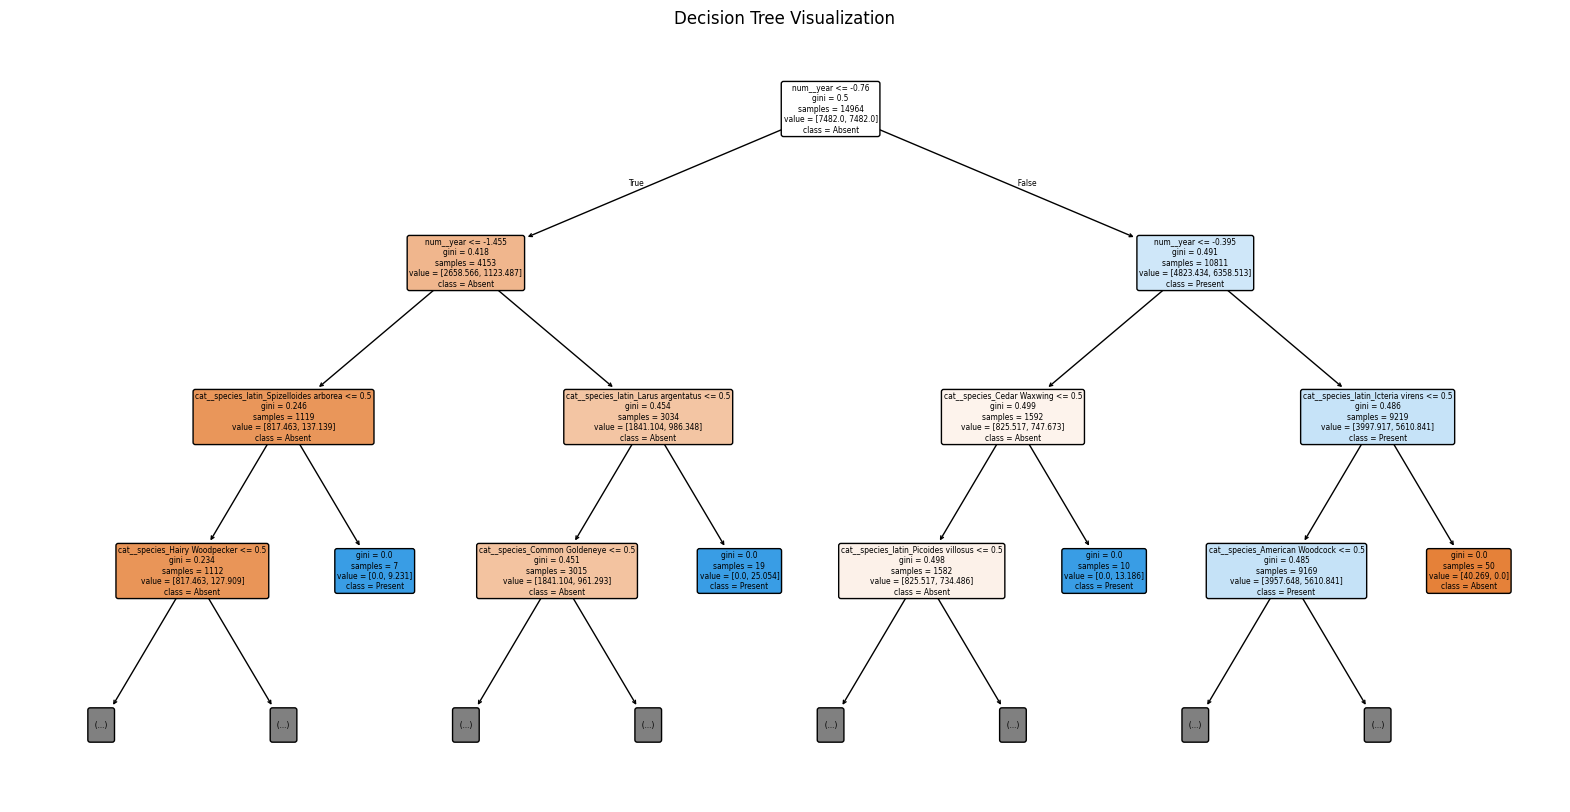

In [75]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

y_pred = dt_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap="OrRd")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


tree_model = dt_model.named_steps["model"]

feature_names = dt_model.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(20,10))

plot_tree(
    tree_model,
    filled=True,
    feature_names=feature_names,
    class_names=["Absent","Present"],
    rounded=True,
    max_depth=3
)
plt.title("Decision Tree Visualization")
plt.show()

In [76]:
#PCA AND SVD 
pipeline_pca = Pipeline([
    ("preprocess", preprocessor),
    ("pca", PCA(n_components=2))
])

pipeline_svd = Pipeline([
    ("preprocess", preprocessor),
    ("svd", TruncatedSVD(n_components=10))  # Increased: more info retained → better models
])

X_train_pca = pipeline_pca.fit_transform(X_train)
X_test_pca  = pipeline_pca.transform(X_test)

X_train_svd = pipeline_svd.fit_transform(X_train)
X_test_svd  = pipeline_svd.transform(X_test)

print("PCA shape:", X_train_pca.shape)
print("SVD shape:", X_train_svd.shape)

PCA shape: (14964, 2)
SVD shape: (14964, 10)


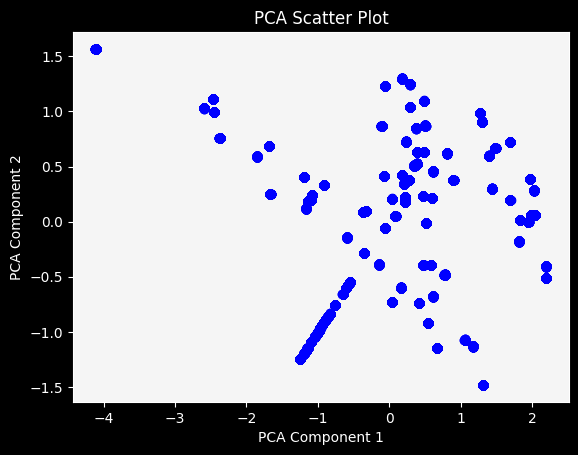

In [95]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.scatter(X_train_pca[:,0], X_train_pca[:,1], color="blue")

# light background
ax.set_facecolor("#f5f5f5")

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_title("PCA Scatter Plot")

plt.show()

In [100]:
from sklearn.decomposition import PCA

X_train_processed = preprocessor.fit_transform(X_train)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_processed)

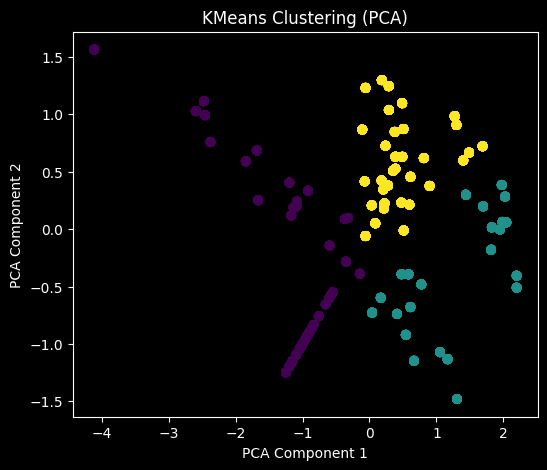

In [106]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=3, random_state=42)

kmeans_labels = kmeans.fit_predict(X_pca)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, cmap="viridis")
plt.title("KMeans Clustering (PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

Accuracy: 0.8567610903260289


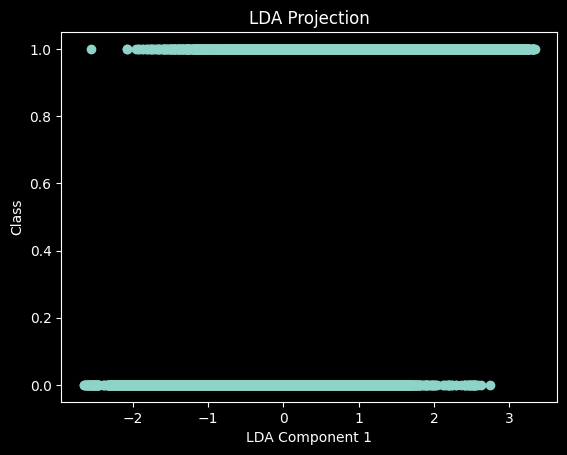

In [122]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report

# convert sparse → dense
X_train_dense = X_train_processed.toarray()
X_test_dense = X_test_processed.toarray()

# LDA model
lda = LinearDiscriminantAnalysis()

# train
lda.fit(X_train_dense, y_train)

# predict
y_pred = lda.predict(X_test_dense)

# evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

import matplotlib.pyplot as plt

X_lda = lda.fit_transform(X_train_dense, y_train)

plt.scatter(X_lda[:,0], y_train)
plt.xlabel("LDA Component 1")
plt.ylabel("Class")
plt.title("LDA Projection")
plt.show()

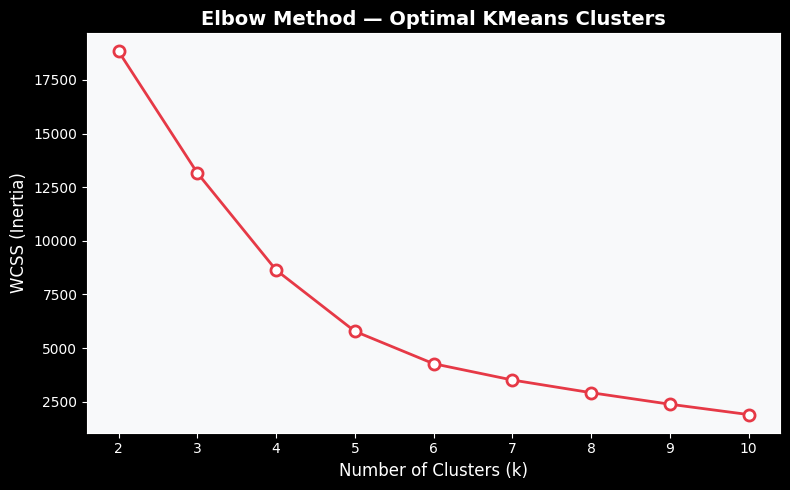


KMeans Clustering Metrics
  Silhouette Score:    0.4561
  Davies Bouldin:      0.7337
  Calinski Harabasz:   17233.6293


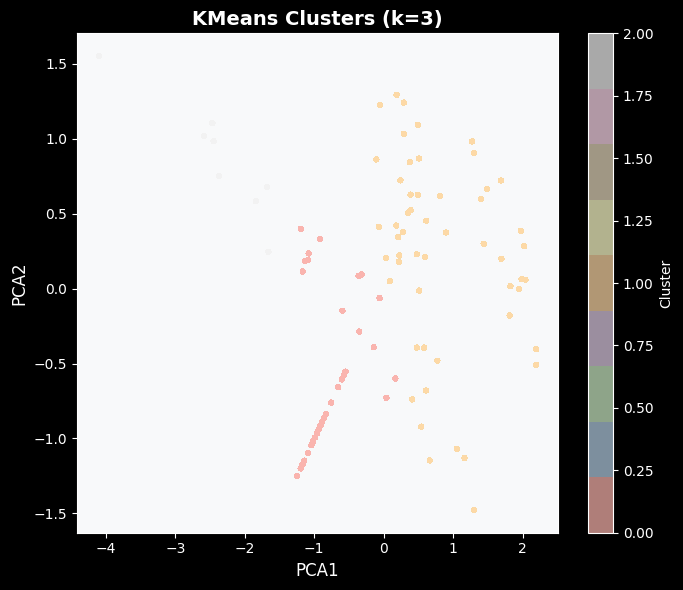

In [116]:
X_cluster = pipeline_pca.fit_transform(X)

# Elbow Method
wcss = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    wcss.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(2, 11), wcss, marker="o", color="#E63946",
        linewidth=2, markersize=8, markerfacecolor="white", markeredgewidth=2)
ax.set_title("Elbow Method — Optimal KMeans Clusters", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Clusters (k)", fontsize=12)
ax.set_ylabel("WCSS (Inertia)", fontsize=12)
ax.set_facecolor("#f8f9fa")
plt.tight_layout()
plt.show()

# Fit KMeans (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
k_labels = kmeans.fit_predict(X_cluster)

print("\nKMeans Clustering Metrics")
print(f"  Silhouette Score:    {silhouette_score(X_cluster, k_labels):.4f}")
print(f"  Davies Bouldin:      {davies_bouldin_score(X_cluster, k_labels):.4f}")
print(f"  Calinski Harabasz:   {calinski_harabasz_score(X_cluster, k_labels):.4f}")

fig, ax = plt.subplots(figsize=(7, 6))

scatter = ax.scatter(
    X_cluster[:, 0], X_cluster[:, 1],
    c=k_labels,
    cmap="Pastel1",   # changed color map
    alpha=0.7,
    s=15,
    edgecolors="none"
)

fig.colorbar(scatter, ax=ax, label="Cluster")

ax.set_title("KMeans Clusters (k=3)", fontsize=14, fontweight="bold")
ax.set_xlabel("PCA1", fontsize=12)
ax.set_ylabel("PCA2", fontsize=12)

ax.set_facecolor("#f8f9fa")

plt.tight_layout()
plt.show()

Agglomerative Clustering Metrics
  Silhouette Score:    0.4369
  Davies Bouldin:      0.8665
  Calinski Harabasz:   15822.1626


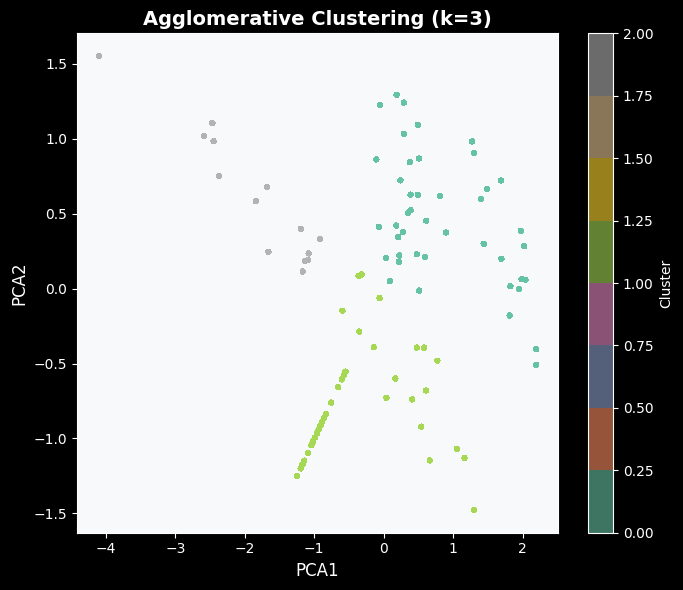

In [118]:
agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X_cluster)

print("Agglomerative Clustering Metrics")
print(f"  Silhouette Score:    {silhouette_score(X_cluster, agg_labels):.4f}")
print(f"  Davies Bouldin:      {davies_bouldin_score(X_cluster, agg_labels):.4f}")
print(f"  Calinski Harabasz:   {calinski_harabasz_score(X_cluster, agg_labels):.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(X_cluster[:, 0], X_cluster[:, 1],
                     c=agg_labels, cmap="Set2", alpha=0.6, s=15, edgecolors="none")
fig.colorbar(scatter, ax=ax, label="Cluster")
ax.set_title("Agglomerative Clustering (k=3)", fontsize=14, fontweight="bold")
ax.set_xlabel("PCA1", fontsize=12)
ax.set_ylabel("PCA2", fontsize=12)
ax.set_facecolor("#f8f9fa")
plt.tight_layout()
plt.show()
